
IMPORT LIBRARY
=

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

LOAD DATA
=

In [2]:
df = pd.read_csv("./Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


CLEAN DATA
=

In [3]:
df = df[["Fare"]].dropna()
data = df["Fare"].dropna().to_numpy()

HITUNG STANDAR MEAN DAN STANDAR DEVIASI
=

In [4]:
mean = df['Fare'].sum() / len(df)
std = ((df['Fare'] - mean) ** 2).sum()
std = (std / len(df)) ** 0.5

HITUNG Z-SCORE
=

In [5]:
df['zscore'] = (df['Fare'] - mean) / std

VISUALISASI KURVA
=

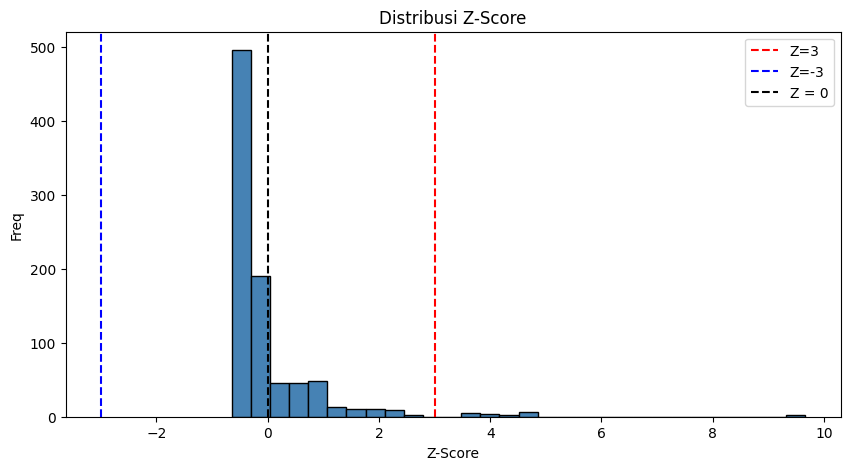

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(df['zscore'], bins=30, color='steelblue', edgecolor='black')
plt.axvline(x=3, color='red', linestyle='--', label='Z=3')
plt.axvline(x=-3, color='blue', linestyle='--', label='Z=-3')
plt.axvline(x=0, color='black', linestyle='--', label='Z = 0')
plt.title('Distribusi Z-Score')
plt.xlabel('Z-Score')
plt.ylabel('Freq')
plt.legend()
plt.show()

In [7]:
outlier_bawah = df[df['zscore'] < -3].count()
outlier_atas = df[df['zscore'] > 3].count()
print("outlier atas:\n", outlier_atas, "\noutlier bawah:\n", outlier_bawah)

outlier atas:
 Fare      20
zscore    20
dtype: int64 
outlier bawah:
 Fare      0
zscore    0
dtype: int64


CLT
=

In [8]:
n = 30
k = 1000

sample_means = []

for _ in range(k):
    sample = np.random.choice(data, size=n, replace=True)
    mean = np.mean(sample)
    sample_means.append(mean)

sample_means = np.array(sample_means)

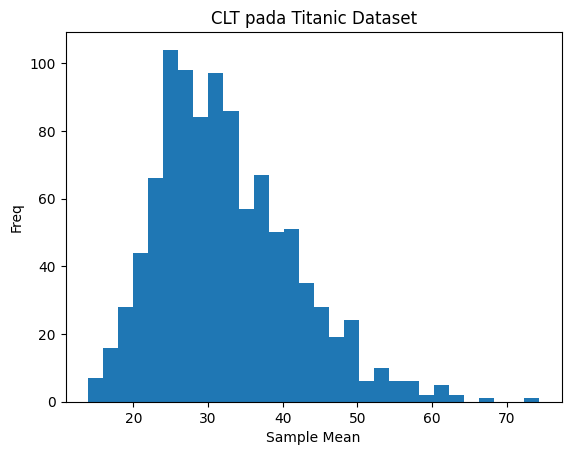

In [9]:
plt.hist(sample_means, bins=30)
plt.title("CLT pada Titanic Dataset")
plt.xlabel("Sample Mean")
plt.ylabel("Freq")
plt.show()

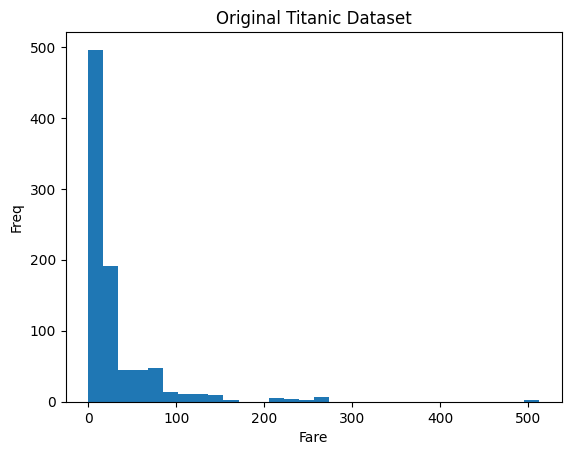

In [10]:
plt.hist(data, bins=30)
plt.title("Original Titanic Dataset")
plt.xlabel("Fare")
plt.ylabel("Freq")
plt.show()